<a href="https://colab.research.google.com/github/alejandrosantanabonilla/AI_tutorials/blob/main/Intro_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Geometry of Data: Understanding Distance Metrics

Before we can use machine learning to cluster customers or find patterns, we have to answer a fundamental philosophical question: **What does it mean for two customers to be "similar"?**

In machine learning, "similarity" is just a measure of **distance** in space. But as you are about to see, *how* we measure that distance completely changes who is considered a neighbor.

In this lab, we will look at three specific customers from a simplified KNIME behavioral dataset:

* **Customer T (The Target):** Low engagement (4 logins, 4 reads).
* **Customer E (The Euclidean Neighbor):** Moderate engagement (7 logins, 4 reads).
* **Customer C (The Cosine Neighbor):** Power user (16 logins, 16 reads).

Let's plot them on a 2D grid and see how the math works.


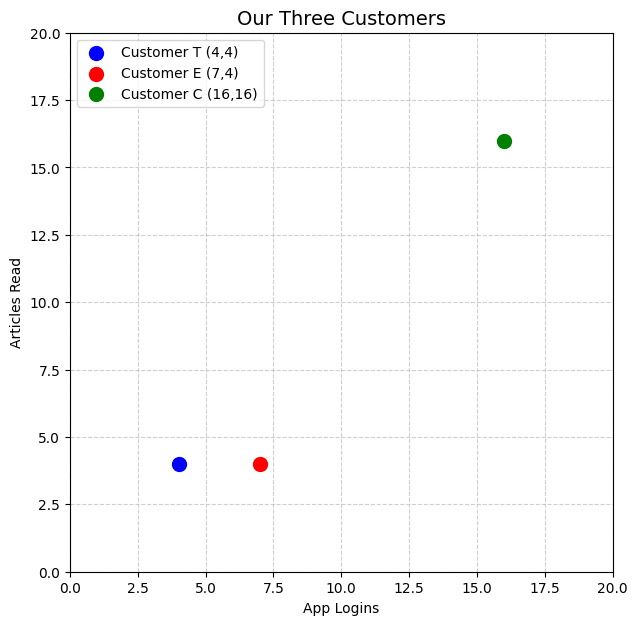

In [1]:
# 1. SETUP AND PLOTTING OUR CUSTOMERS
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

# Define our three specific customers (X = Logins, Y = Articles Read)
T = np.array([4, 4])   # Target Customer
E = np.array([7, 4])   # Customer E
C = np.array([16, 16]) # Customer C

# Helper function to set up our graph perfectly every time
def setup_graph(title):
    plt.figure(figsize=(7, 7)) # Keep it perfectly square
    plt.xlim(0, 20)
    plt.ylim(0, 20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel("App Logins")
    plt.ylabel("Articles Read")
    plt.title(title, fontsize=14)

    # Plot the points
    plt.scatter(*T, color='blue', s=100, zorder=5, label='Customer T (4,4)')
    plt.scatter(*E, color='red', s=100, zorder=5, label='Customer E (7,4)')
    plt.scatter(*C, color='green', s=100, zorder=5, label='Customer C (16,16)')
    plt.legend(loc='upper left')

setup_graph("Our Three Customers")
plt.show()

## 1. Euclidean Distance ($L_2$ Norm)

Euclidean distance is the "straight line" distance. It is exactly how we measure space in the physical world. If you were a bird flying from Customer T to Customer E, you would take the Euclidean path.

**Formula:** $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$ (The Pythagorean theorem!)

Let's visualize the Euclidean distance from **T** to **E**, and from **T** to **C**.


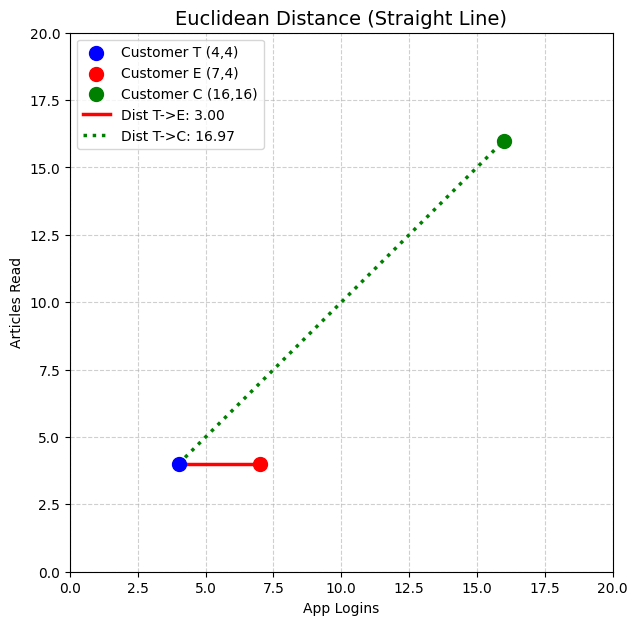

According to Euclidean math, Customer E is MUCH closer to T than Customer C is.


In [5]:
# Calculate Euclidean Distances
dist_TE_euclidean = distance.euclidean(T, E)
dist_TC_euclidean = distance.euclidean(T, C)

setup_graph("Euclidean Distance (Straight Line)")

# Draw Euclidean paths
plt.plot([T[0], E[0]], [T[1], E[1]], color='red', linewidth=2.5, label=f'Dist T->E: {dist_TE_euclidean:.2f}')
plt.plot([T[0], C[0]], [T[1], C[1]], color='green', linewidth=2.5, linestyle=':', label=f'Dist T->C: {dist_TC_euclidean:.2f}')

plt.legend(loc='upper left')
plt.show()

print(f"According to Euclidean math, Customer E is MUCH closer to T than Customer C is.")

## 2. Manhattan Distance ($L_1$ Norm)

Imagine you are a taxi driver in New York City. You can't drive through buildings (a straight line); you have to drive along the city blocks.

Manhattan distance calculates the distance by moving strictly horizontally, and then strictly vertically. In high-dimensional machine learning (like hundreds of features), Manhattan often performs better than Euclidean because it prevents massive outliers in a single feature from breaking the math.


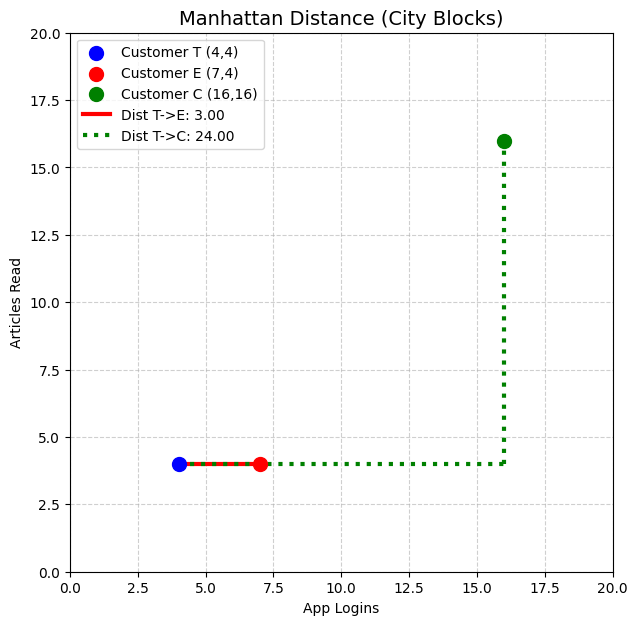

Manhattan distance makes the gap between T and C even larger because it can't cut corners.


In [3]:
# Calculate Manhattan Distances (Cityblock)
dist_TE_manhattan = distance.cityblock(T, E)
dist_TC_manhattan = distance.cityblock(T, C)

setup_graph("Manhattan Distance (City Blocks)")

# Draw Manhattan path T -> E
plt.plot([T[0], E[0]], [T[1], T[1]], color='red', linewidth=3) # Horizontal
plt.plot([E[0], E[0]], [T[1], E[1]], color='red', linewidth=3, label=f'Dist T->E: {dist_TE_manhattan:.2f}') # Vertical

# Draw Manhattan path T -> C
plt.plot([T[0], C[0]], [T[1], T[1]], color='green', linewidth=3, linestyle=':') # Horizontal
plt.plot([C[0], C[0]], [T[1], C[1]], color='green', linewidth=3, linestyle=':', label=f'Dist T->C: {dist_TC_manhattan:.2f}') # Vertical

plt.legend(loc='upper left')
plt.show()

print(f"Manhattan distance makes the gap between T and C even larger because it can't cut corners.")

## 3. Cosine Distance (The Game Changer)

The Cosine distance completely ignores the **magnitude** (how big the numbers are) and only looks at the **angle** or direction from the origin (0,0).

Think of it like behavioral ratios.

* Customer **T** logged in 4 times and read 4 articles (a 1:1 ratio).
* Customer **C** logged in 16 times and read 16 articles (also a 1:1 ratio).

Even though they are far apart in raw numbers, their *behavioral pattern* is identical. Cosine distance visualizes each customer as an arrow shooting out from zero. If the arrows point in the exact same direction, the distance is 0.


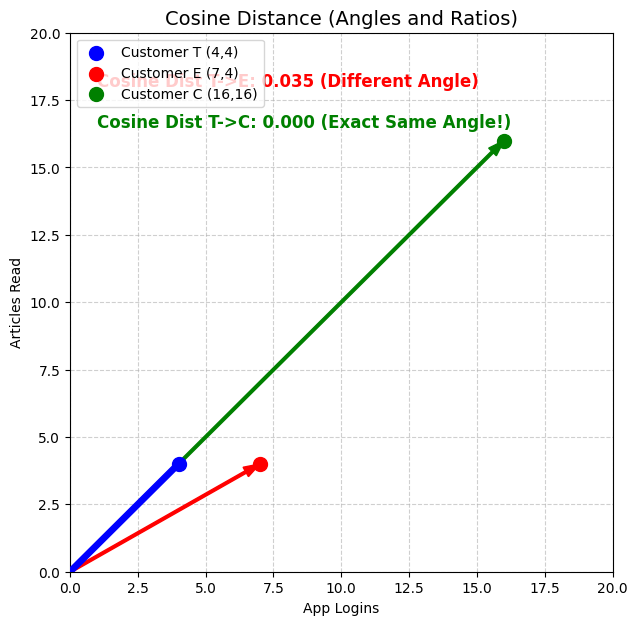

In [4]:
# Calculate Cosine Distances
# Note: scipy calculates distance, which is (1 - cosine_similarity).
# Distance of 0 means identical angles.
dist_TE_cosine = distance.cosine(T, E)
dist_TC_cosine = distance.cosine(T, C)

setup_graph("Cosine Distance (Angles and Ratios)")

# Draw arrows from the origin (0,0)
origin = [0, 0]

# Arrow for T and C (They lie on the exact same line!)
plt.arrow(*origin, *C, color='green', width=0.1, head_width=0.4, length_includes_head=True, zorder=3)
plt.arrow(*origin, *T, color='blue', width=0.2, head_width=0, length_includes_head=True, zorder=4)

# Arrow for E
plt.arrow(*origin, *E, color='red', width=0.1, head_width=0.4, length_includes_head=True, zorder=3)

# Add text to show the distances
plt.text(1, 18, f"Cosine Dist T->E: {dist_TE_cosine:.3f} (Different Angle)", color='red', fontsize=12, fontweight='bold')
plt.text(1, 16.5, f"Cosine Dist T->C: {dist_TC_cosine:.3f} (Exact Same Angle!)", color='green', fontsize=12, fontweight='bold')

plt.show()

> **Instructor Discussion Prompt:**
> Look at the final chart.
> * If we use **Euclidean** distance, the algorithm will group Customer T with Customer E.
> * If we use **Cosine** distance, the algorithm will group Customer T with Customer C.
>
>
> If you were trying to build a recommendation engine for Netflix or Amazon, which metric do you think is more useful, and why?